In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append(f"./../")

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import RXGate
from src.mcrx_simplifier import MCRXCascadeSimplifier
from src.misc import (
    get_state, 
    compare_quantum_states, 
    multi_crx,
    count_gates_direct_transpilation
)

In [2]:
def run_example(qc_original, description):
    """Run optimization example with comprehensive analysis."""
    print(f"\n{'='*80}")
    print(f"EXAMPLE: {description}")
    print(f"{'='*80}")
    
    # Initialize default return values
    qc_optimized = None
    cx_count_opt, u3_count_opt, transpiled_opt = 0, 0, False
    method_opt = "Failed"
    optimization_info = {}
    equivalence = "? UNKNOWN"
    state_results = None
    
    try:
        # Create original circuit
        # qc_original = circuit_creation_func()
        
        print(f"\n--- Original Circuit ---")
        print(qc_original.draw())
        print(f"Original gates: {len(qc_original.data)}")
        print(f"Original depth: {qc_original.depth()}")
        
        # Get gate counts for original circuit
        cx_count_orig, u3_count_orig, transpiled_orig, _, _ = count_gates_direct_transpilation(qc_original)
        method_orig = "Transpiled" if transpiled_orig else "Estimated"
        print(f"Gate counts ({method_orig}) - CX: {cx_count_orig}, U3: {u3_count_orig}")
        
        # Initialize the simplifier
        simplifier = MCRXCascadeSimplifier(tolerance=1e-10, verbose=True)
        
        # Initialize optimization variables with defaults
        qc_optimized = qc_original
        cx_count_opt, u3_count_opt, transpiled_opt = cx_count_orig, u3_count_orig, transpiled_orig
        method_opt = method_orig
        
        # Perform optimization
        print(f"\n--- Applying Optimization ---")
        try:
            # Handle different API formats
            result = simplifier.simplify(qc_original)
            
            # Check if new API (returns tuple) or old API (returns circuit)
            if isinstance(result, tuple) and len(result) == 2:
                qc_optimized, optimization_info = result
                print(f"✓ New API detected - optimization info available")
            else:
                qc_optimized = result
                optimization_info = {}
                print(f"✓ Old API detected - basic optimization only")
            
            if qc_optimized is not None:
                print(f"\n--- Optimized Circuit ---")
                print(qc_optimized.draw())
                print(f"Optimized gates: {len(qc_optimized.data)}")
                print(f"Optimized depth: {qc_optimized.depth()}")
                
                # Print additional optimization details if available
                if optimization_info:
                    print(f"CNOT tricks used: {optimization_info.get('uses_cnot_tricks', False)}")
                    print(f"Total multi_crx calls: {optimization_info.get('total_multi_crx_calls', 'N/A')}")
                    if optimization_info.get('final_gates'):
                        print(f"Final gate calls: {optimization_info['final_gates']}")
                
                # Get gate counts for optimized circuit
                cx_count_opt, u3_count_opt, transpiled_opt, _, _ = count_gates_direct_transpilation(qc_optimized)
                method_opt = "Transpiled" if transpiled_opt else "Estimated"
                print(f"Gate counts ({method_opt}) - CX: {cx_count_opt}, U3: {u3_count_opt}")
            else:
                print("Optimization returned None - using original circuit")
                qc_optimized = qc_original
            
        except Exception as e:
            print(f"Optimization failed: {e}")
            qc_optimized = qc_original
        
        # State equivalence verification
        print(f"\n--- State Equivalence Verification ---")
        try:
            state_original = get_state(qc_original)
            state_optimized = get_state(qc_optimized)
            
            # Use state analysis
            state_results = compare_quantum_states(
                state_original, 
                state_optimized, 
                tolerance=1e-10, 
                verbose=True
            )
            
            if state_results['amplitudes_match']:
                print("✓ States are EQUIVALENT")
                equivalence = "✓ EQUIVALENT"
            else:
                print("✗ States are NOT equivalent")
                print(f"  Max difference: {state_results.get('max_difference', 'N/A')}")
                equivalence = "✗ NOT EQUIVALENT"
                
        except Exception as e:
            print(f"State verification failed: {e}")
            equivalence = "? VERIFICATION FAILED"
            state_results = {'fidelity': 0.0}
        
        # Calculate performance metrics
        print(f"\n--- Performance Summary ---")
        cx_reduction = max(0, cx_count_orig - cx_count_opt)
        u3_reduction = max(0, u3_count_orig - u3_count_opt)
        total_reduction = cx_reduction + u3_reduction
        
        cx_pct = (cx_reduction / max(1, cx_count_orig)) * 100
        u3_pct = (u3_reduction / max(1, u3_count_orig)) * 100
        total_pct = (total_reduction / max(1, cx_count_orig + u3_count_orig)) * 100
        
        depth_orig = qc_original.depth()
        depth_opt = qc_optimized.depth()
        depth_reduction = max(0, depth_orig - depth_opt)
        depth_pct = (depth_reduction / max(1, depth_orig)) * 100
        
        analysis_method = f"{method_orig}/{method_opt}"
        
        print(f"Analysis method: {analysis_method}")
        print(f"CX gate reduction: {cx_reduction} ({cx_pct:.1f}%)")
        print(f"U3 gate reduction: {u3_reduction} ({u3_pct:.1f}%)")
        print(f"Total gate reduction: {total_reduction} ({total_pct:.1f}%)")
        print(f"Depth reduction: {depth_reduction} ({depth_pct:.1f}%)")
        print(f"Fidelity: {state_results.get('fidelity', 0.0):.10f}")
        
        # Print detailed optimization summary if available
        if optimization_info and hasattr(simplifier, 'print_optimization_summary'):
            print(f"\n--- Detailed Optimization Summary ---")
            try:
                simplifier.print_optimization_summary(optimization_info)
            except Exception as e:
                print(f"Could not print detailed summary: {e}")
        
        return {
            'equivalence': equivalence,
            'gate_reduction': total_pct,
            'depth_reduction': depth_pct,
            'cx_reduction': cx_pct,
            'u3_reduction': u3_pct,
            'analysis_method': analysis_method,
            'optimization_info': optimization_info,
            'transpiled_counts': {
                'original': {'cx': cx_count_orig, 'u3': u3_count_orig},
                'optimized': {'cx': cx_count_opt, 'u3': u3_count_opt}
            }
        }
        
    except Exception as e:
        print(f"Critical error: {e}")
        return {
            'equivalence': "✗ FAILED",
            'gate_reduction': 0,
            'depth_reduction': 0,
            'cx_reduction': 0,
            'u3_reduction': 0,
            'analysis_method': "Failed",
            'optimization_info': {},
            'transpiled_counts': None
        }


In [3]:
# Example 1: Fully Disjoint Control Patterns
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '10')
rx2 = multi_crx(theta, '01')
qc.append(rx1, [0, 1, 2])
qc.append(rx2, [0, 1, 2])


result1 = run_example(qc, "Fully Disjoint Control Patterns ['10', '01']")


EXAMPLE: Fully Disjoint Control Patterns ['10', '01']

--- Original Circuit ---
                           
q_0: ─────■──────────o─────
          │          │     
q_1: ─────o──────────■─────
     ┌────┴────┐┌────┴────┐
q_2: ┤ Rx(π/4) ├┤ Rx(π/4) ├
     └─────────┘└─────────┘
Original gates: 2
Original depth: 2
Gate counts (Transpiled) - CX: 16, U3: 17

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
✓ Circuit validated: target=2, angle=0.7854, controls=2
✓ Extracted 2 patterns:
  ControlPattern('10', coeff=1, qubits=[0, 1])
  ControlPattern('01', coeff=1, qubits=[0, 1])
  Basic simplification: 2 patterns
    ControlPattern('10', coeff=1, qubits=[0, 1])
    ControlPattern('01', coeff=1, qubits=[0, 1])
    Original expr: (x0 & ~x1) | (x1 & ~x0)
    Simplified expr: (x0 & ~x1) | (x1 & ~x0)
    Single var: False
    Negated var: False
    XOR pairs found: 1
      10 ⊕ 01 at positions [0, 1]
    Different control sets: False
    Applyin

In [4]:
# Example 2: Partially Overlapping Control Patterns  
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '11')
rx2 = multi_crx(theta, '10')
qc.append(rx1, [0, 1, 2])
qc.append(rx2, [0, 1, 2])


result2 = run_example(qc, "Partially Overlapping Control Patterns ['11', '10']")



EXAMPLE: Partially Overlapping Control Patterns ['11', '10']

--- Original Circuit ---
                           
q_0: ─────■──────────■─────
          │          │     
q_1: ─────■──────────o─────
     ┌────┴────┐┌────┴────┐
q_2: ┤ Rx(π/4) ├┤ Rx(π/4) ├
     └─────────┘└─────────┘
Original gates: 2
Original depth: 2
Gate counts (Transpiled) - CX: 16, U3: 15

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
✓ Circuit validated: target=2, angle=0.7854, controls=2
✓ Extracted 2 patterns:
  ControlPattern('11', coeff=1, qubits=[0, 1])
  ControlPattern('10', coeff=1, qubits=[0, 1])
  Basic simplification: 2 patterns
    ControlPattern('11', coeff=1, qubits=[0, 1])
    ControlPattern('10', coeff=1, qubits=[0, 1])
    Original expr: (x0 & x1) | (x0 & ~x1)
    Simplified expr: x0
    Single var: True
    Negated var: False
    XOR pairs found: 0
    Different control sets: False
    Applying single control optimization
    Final method: si

In [5]:
# Example 3: Complex Overlapping (3-qubit controls)

theta = 2 * np.pi / 4  # π/2
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '110')
rx2 = multi_crx(theta, '101')
qc.append(rx1, [0, 1, 2, 3])
qc.append(rx2, [0, 1, 2, 3])


result3 = run_example(qc, "Complex Overlapping Control Patterns ['110', '101']")


EXAMPLE: Complex Overlapping Control Patterns ['110', '101']

--- Original Circuit ---
                           
q_0: ─────■──────────■─────
          │          │     
q_1: ─────■──────────o─────
          │          │     
q_2: ─────o──────────■─────
     ┌────┴────┐┌────┴────┐
q_3: ┤ Rx(π/2) ├┤ Rx(π/2) ├
     └─────────┘└─────────┘
Original gates: 2
Original depth: 2
Gate counts (Transpiled) - CX: 40, U3: 33

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
✓ Circuit validated: target=3, angle=1.5708, controls=3
✓ Extracted 2 patterns:
  ControlPattern('110', coeff=1, qubits=[0, 1, 2])
  ControlPattern('101', coeff=1, qubits=[0, 1, 2])
  Basic simplification: 2 patterns
    ControlPattern('110', coeff=1, qubits=[0, 1, 2])
    ControlPattern('101', coeff=1, qubits=[0, 1, 2])
    Original expr: (x0 & x1 & ~x2) | (x0 & x2 & ~x1)
    Simplified expr: x0 & (x1 | x2) & (~x1 | ~x2)
    Single var: False
    Negated var: False
    XOR 

In [6]:
# Example 4: Subset Control Patterns
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '11')
qc.append(rx1, [0, 1, 2])
# Fixed: Use MCRX instead of CRX to maintain same target requirement
rx2 = multi_crx(theta, '1')  # This is effectively a '1X' pattern where X can be 0 or 1
qc.append(rx2, [0, 2])  # Only qubit 0 as control, same target qubit 2

result4 = run_example(qc, "Subset Control Patterns ['11'] + MCRX('1', 0->2)")


EXAMPLE: Subset Control Patterns ['11'] + MCRX('1', 0->2)

--- Original Circuit ---
                           
q_0: ─────■──────────■─────
          │          │     
q_1: ─────■──────────┼─────
     ┌────┴────┐┌────┴────┐
q_2: ┤ Rx(π/4) ├┤ Rx(π/4) ├
     └─────────┘└─────────┘
Original gates: 2
Original depth: 2
Gate counts (Transpiled) - CX: 8, U3: 10

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
✓ Circuit validated: target=2, angle=0.7854, controls=2
✓ Extracted 2 patterns:
  ControlPattern('11', coeff=1, qubits=[0, 1])
  ControlPattern('1', coeff=1, qubits=[0])
  Basic simplification: 2 patterns
    ControlPattern('11', coeff=1, qubits=[0, 1])
    ControlPattern('1', coeff=1, qubits=[0])
    Original expr: x0 | (x0 & x1)
    Simplified expr: x0
    Single var: True
    Negated var: False
    XOR pairs found: 0
    Different control sets: True
    Final method: no_optimization_different_controls
    Gate reduction: 0
✓ New A

In [7]:
# Example 5: Identical Control Patterns

theta = np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '110')
rx2 = multi_crx(theta, '110')
qc.append(rx1, [0, 1, 2, 3])
qc.append(rx2, [0, 1, 2, 3])

result5 = run_example(qc, "Identical Control Patterns ['110', '110']")


EXAMPLE: Identical Control Patterns ['110', '110']

--- Original Circuit ---
                           
q_0: ─────■──────────■─────
          │          │     
q_1: ─────■──────────■─────
          │          │     
q_2: ─────o──────────o─────
     ┌────┴────┐┌────┴────┐
q_3: ┤ Rx(π/4) ├┤ Rx(π/4) ├
     └─────────┘└─────────┘
Original gates: 2
Original depth: 2
Gate counts (Transpiled) - CX: 40, U3: 31

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
✓ Circuit validated: target=3, angle=0.7854, controls=3
✓ Extracted 1 patterns:
  ControlPattern('110', coeff=2, qubits=[0, 1, 2])
  Basic simplification: 1 patterns
    ControlPattern('110', coeff=2, qubits=[0, 1, 2])
    Original expr: x0 & x1 & ~x2
    Simplified expr: x0 & x1 & ~x2
    Single var: False
    Negated var: False
    XOR pairs found: 0
    Different control sets: False
    Final method: identical_patterns
    Gate reduction: 1
✓ New API detected - optimization info av

In [8]:
theta = np.pi / 4
qc = QuantumCircuit(5)
qc.x(1)


result = run_example(qc, "expr = x0 & ~x2 | x0 & x2")


EXAMPLE: expr = x0 & ~x2 | x0 & x2

--- Original Circuit ---
          
q_0: ─────
     ┌───┐
q_1: ┤ X ├
     └───┘
q_2: ─────
          
q_3: ─────
          
q_4: ─────
          
Original gates: 1
Original depth: 1
Gate counts (Transpiled) - CX: 0, U3: 1

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
Optimization failed: list index out of range

--- State Equivalence Verification ---
State Comparison Results:
Fidelity: 1.0000000000
Amplitudes match (tolerance=1e-10): True
Maximum amplitude difference: 0.00e+00
All amplitudes match within tolerance!
✓ States are EQUIVALENT

--- Performance Summary ---
Analysis method: Transpiled/Transpiled
CX gate reduction: 0 (0.0%)
U3 gate reduction: 0 (0.0%)
Total gate reduction: 0 (0.0%)
Depth reduction: 0 (0.0%)
Fidelity: 1.0000000000


In [9]:

theta = np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '11')
rx2 = multi_crx(theta, '10')
qc.append(rx1, [0, 2, 1])
qc.append(rx2, [0, 2, 1])

result = run_example(qc, "expr = x0 & ~x2 | x0 & x2")


EXAMPLE: expr = x0 & ~x2 | x0 & x2

--- Original Circuit ---
                           
q_0: ─────■──────────■─────
     ┌────┴────┐┌────┴────┐
q_1: ┤ Rx(π/4) ├┤ Rx(π/4) ├
     └────┬────┘└────┬────┘
q_2: ─────■──────────o─────
                           
q_3: ──────────────────────
                           
Original gates: 2
Original depth: 2
Gate counts (Transpiled) - CX: 16, U3: 15

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
✓ Circuit validated: target=1, angle=0.7854, controls=2
✓ Extracted 2 patterns:
  ControlPattern('11', coeff=1, qubits=[0, 2])
  ControlPattern('10', coeff=1, qubits=[0, 2])
  Basic simplification: 2 patterns
    ControlPattern('11', coeff=1, qubits=[0, 2])
    ControlPattern('10', coeff=1, qubits=[0, 2])
    Original expr: (x0 & x2) | (x0 & ~x2)
    Simplified expr: x0
    Single var: True
    Negated var: False
    XOR pairs found: 0
    Different control sets: False
    Applying single control opt

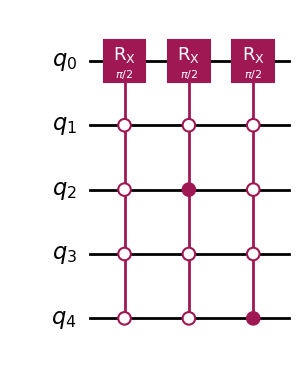


EXAMPLE: expr = ~x1 & ~x2 & ~x3 & ~x4 | ~x1 & x2 & ~x3 & ~x4 | ~x1 & ~x2 & ~x3 & x4

--- Original Circuit ---
     ┌─────────┐┌─────────┐┌─────────┐
q_0: ┤ Rx(π/2) ├┤ Rx(π/2) ├┤ Rx(π/2) ├
     └────┬────┘└────┬────┘└────┬────┘
q_1: ─────o──────────o──────────o─────
          │          │          │     
q_2: ─────o──────────■──────────o─────
          │          │          │     
q_3: ─────o──────────o──────────o─────
          │          │          │     
q_4: ─────o──────────o──────────■─────
                                      
Original gates: 3
Original depth: 3
Gate counts (Transpiled) - CX: 72, U3: 84

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
✓ Circuit validated: target=0, angle=1.5708, controls=4
✓ Extracted 3 patterns:
  ControlPattern('0000', coeff=1, qubits=[1, 2, 3, 4])
  ControlPattern('0100', coeff=1, qubits=[1, 2, 3, 4])
  ControlPattern('0001', coeff=1, qubits=[1, 2, 3, 4])
🔄 Applying iterative pairwise simp

In [10]:

theta = np.pi / 2
qc = QuantumCircuit(5)
mcrx1 = multi_crx(theta, '0000')
mcrx2 = multi_crx(theta, '0100')
mcrx3 = multi_crx(theta, '0001')
qc.append(mcrx1, [1, 2, 3, 4, 0])
qc.append(mcrx2, [1, 2, 3, 4, 0])
qc.append(mcrx3, [1, 2, 3, 4, 0])
display(qc.draw('mpl'))

result = run_example(qc, "expr = ~x1 & ~x2 & ~x3 & ~x4 | ~x1 & x2 & ~x3 & ~x4 | ~x1 & ~x2 & ~x3 & x4")

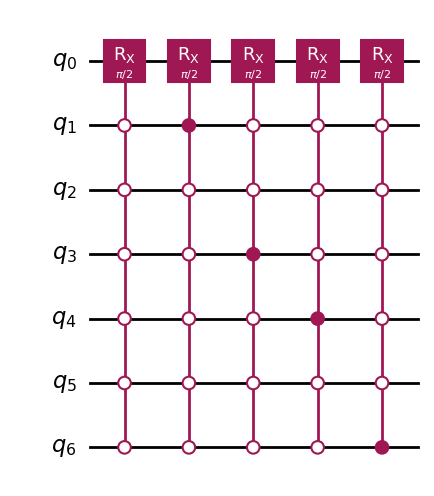


EXAMPLE: expr = ~x0 & ~x1 & ~x2 & ~x4 & ~x5 & ~x6 
| x0 & ~x1 & ~x2 & ~x4 & ~x5 & ~x6 
| ~x0 & ~x1 & x2 & ~x4 & ~x5 & ~x6 
| ~x0 & ~x1 & ~x2 & x4 & ~x5 & ~x6 
| ~x0 & ~x1 & ~x2 & ~x4 & ~x5 & x6 


--- Original Circuit ---
     ┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐
q_0: ┤ Rx(π/2) ├┤ Rx(π/2) ├┤ Rx(π/2) ├┤ Rx(π/2) ├┤ Rx(π/2) ├
     └────┬────┘└────┬────┘└────┬────┘└────┬────┘└────┬────┘
q_1: ─────o──────────■──────────o──────────o──────────o─────
          │          │          │          │          │     
q_2: ─────o──────────o──────────o──────────o──────────o─────
          │          │          │          │          │     
q_3: ─────o──────────o──────────■──────────o──────────o─────
          │          │          │          │          │     
q_4: ─────o──────────o──────────o──────────■──────────o─────
          │          │          │          │          │     
q_5: ─────o──────────o──────────o──────────o──────────o─────
          │          │          │          │ 

In [15]:

theta = np.pi / 2
qc = QuantumCircuit(7)
mcrx1 = multi_crx(theta, '000000')
mcrx2 = multi_crx(theta, '100000')
mcrx3 = multi_crx(theta, '001000')
mcrx4 = multi_crx(theta, '000100')
mcrx5 = multi_crx(theta, '000001')
qc.append(mcrx1, [1, 2, 3, 4, 5, 6, 0])
qc.append(mcrx2, [1, 2, 3, 4, 5, 6, 0])
qc.append(mcrx3, [1, 2, 3, 4, 5, 6, 0])
qc.append(mcrx4, [1, 2, 3, 4, 5, 6, 0])
qc.append(mcrx5, [1, 2, 3, 4, 5, 6, 0])
display(qc.draw('mpl'))

result = run_example(qc, 
'''expr = ~x0 & ~x1 & ~x2 & ~x4 & ~x5 & ~x6 
| x0 & ~x1 & ~x2 & ~x4 & ~x5 & ~x6 
| ~x0 & ~x1 & x2 & ~x4 & ~x5 & ~x6 
| ~x0 & ~x1 & ~x2 & x4 & ~x5 & ~x6 
| ~x0 & ~x1 & ~x2 & ~x4 & ~x5 & x6 
'''
)

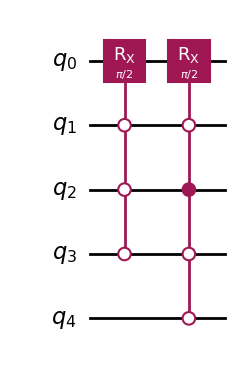

In [11]:
theta = np.pi / 2
qc_simplified = QuantumCircuit(5)
mcrx1 = multi_crx(theta, '000')
mcrx2 = multi_crx(theta, '0100')
mcrx3 = multi_crx(theta, '0001')
qc_simplified.append(mcrx1, [1, 2, 3, 0])
qc_simplified.append(mcrx2, [1, 2, 3, 4, 0])
# qc_simplified.append(mcrx3, [1, 2, 3, 4, 0])
display(qc_simplified.draw('mpl'))

In [12]:
from src.misc import detailed_state_analysis, analyze_circuit_comparison

state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 5
Non-zero amplitudes (tolerance=1e-10):
State   Amplitude 1     Amplitude 2     Difference   Match
-------------------------------------------------------
|00000⟩ 0.125000-0.125000j 0.125000-0.125000j    3.10e-17     ✓
|00001⟩ 0.125000-0.125000j 0.125000-0.125000j    3.10e-17     ✓
|00010⟩ 0.176777+0.000000j 0.176777+0.000000j    5.56e-17     ✓
|00011⟩ 0.176777+0.000000j 0.176777+0.000000j    5.56e-17     ✓
|00100⟩ 0.125000-0.125000j 0.125000-0.125000j    5.55e-17     ✓
|00101⟩ 0.125000-0.125000j 0.125000-0.125000j    5.55e-17     ✓
|00110⟩ 0.176777+0.000000j 0.176777-0.000000j    3.24e-17     ✓
|00111⟩ 0.176777+0.000000j 0.176777+0.000000j    2.79e-17     ✓
|01000⟩ 0.176777+0.000000j 0.176777+0.000000j    1.47e-17     ✓
|01001⟩ 0.176777+0.000000j 0.176777+0.000000j    1.47e-17     ✓
|01010⟩ 0.176777+0.000000j 0.176777+0.000000j    1.47e-17     ✓
|01011⟩ 0.176777+0.000000j 0.176777+0.000000j    1.47e-17     ✓
|01100⟩ 0.

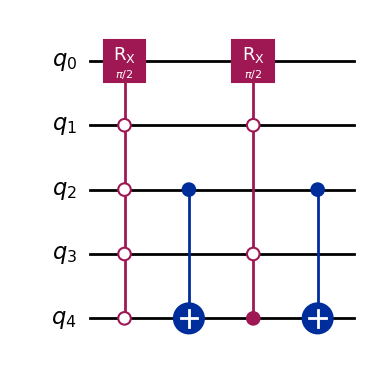

In [13]:
theta = np.pi / 2
qc_simplified = QuantumCircuit(5)
mcrx1 = multi_crx(theta, '0000')
mcrx2 = multi_crx(theta, '0100')
mcrx3 = multi_crx(theta, '001')
qc_simplified.append(mcrx1, [1, 2, 3, 4, 0])
qc_simplified.cx(2, 4)
qc_simplified.append(mcrx3, [1, 3, 4, 0])
qc_simplified.cx(2, 4)
# qc_simplified.append(mcrx3, [1, 2, 3, 4, 0])
display(qc_simplified.draw('mpl'))

In [14]:
from src.misc import detailed_state_analysis, analyze_circuit_comparison

state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 5
Non-zero amplitudes (tolerance=1e-10):
State   Amplitude 1     Amplitude 2     Difference   Match
-------------------------------------------------------
|00000⟩ 0.125000-0.125000j 0.125000-0.125000j    6.21e-17     ✓
|00001⟩ 0.125000-0.125000j 0.125000-0.125000j    1.08e-16     ✓
|00010⟩ 0.176777+0.000000j 0.176777+0.000000j    2.82e-17     ✓
|00011⟩ 0.176777+0.000000j 0.176777+0.000000j    8.34e-17     ✓
|00100⟩ 0.125000-0.125000j 0.125000-0.125000j    9.31e-17     ✓
|00101⟩ 0.125000-0.125000j 0.125000-0.125000j    1.45e-16     ✓
|00110⟩ 0.176777+0.000000j 0.176777+0.000000j    5.57e-17     ✓
|00111⟩ 0.176777+0.000000j 0.176777+0.000000j    8.34e-17     ✓
|01000⟩ 0.176777+0.000000j 0.176777+0.000000j    6.94e-18     ✓
|01001⟩ 0.176777+0.000000j 0.176777+0.000000j    2.86e-17     ✓
|01010⟩ 0.176777+0.000000j 0.176777+0.000000j    5.55e-17     ✓
|01011⟩ 0.176777+0.000000j 0.176777+0.000000j    5.55e-17     ✓
|01100⟩ 0.